## Load Data and Drop Channel and Snipping

In [16]:
import numpy as np

data = np.load("Datasets/d.npz")
X = data["X_raw"]
y = data["y"]  

BAD_CHANNELS = [0]
X = np.delete(X, BAD_CHANNELS, axis=1)
print(X.shape)


(60, 7, 1750)


## Bandpassing

In [17]:
import numpy as np
from brainflow.data_filter import (
    DataFilter,
    FilterTypes,
    DetrendOperations
)

SAMPLING_RATE = 250  
LOW_CUT = 3.0
HIGH_CUT = 45.0
FILTER_ORDER = 4

X_filtered = np.copy(X)

for trial in range(X.shape[0]):

    for ch in range(X.shape[1]):

        signal = X_filtered[trial, ch]
        signal = np.ascontiguousarray(
            signal,
            dtype=np.float64
        )

        # Remove DC offset
        DataFilter.detrend(
            signal,
            DetrendOperations.CONSTANT.value
        )

        # 3–45 Hz Bandpass
        DataFilter.perform_bandpass(
            signal,
            SAMPLING_RATE,
            LOW_CUT,
            HIGH_CUT,
            FILTER_ORDER,
            FilterTypes.BUTTERWORTH_ZERO_PHASE.value,
            0
        )

        DataFilter.remove_environmental_noise(
            signal,
            SAMPLING_RATE,
            1
        )

        X_filtered[trial, ch] = signal

print("Original Shape :", X.shape)
print("Filtered Shape :", X_filtered.shape)

X = X_filtered

Original Shape : (60, 7, 1750)
Filtered Shape : (60, 7, 1750)


## Data Snipping

In [18]:
X_snipped = X[:, :, 500:-500]
X = X_snipped
print("Original Shape :", X.shape)
print("Snipped Shape  :", X_snipped.shape)

Original Shape : (60, 7, 750)
Snipped Shape  : (60, 7, 750)


## Noisy Trial Rejection

In [ ]:
import numpy as np

def reject_noisy_trials(
    X,
    y,
    max_abs_thresh=15500,  
    ptp_thresh=15000,          
    std_z_thresh=4.0,
    flat_std_thresh=1e-6
):
    """
    X shape: (trials, channels, samples)
    y shape: (trials,)
    """

    # Per trial/channel stats
    max_abs = np.max(np.abs(X), axis=2)          # (trials, channels)
    ptp = np.ptp(X, axis=2)                      # (trials, channels)
    std = np.std(X, axis=2)                      # (trials, channels)

    # Trial-level summaries
    trial_max_abs = np.max(max_abs, axis=1)
    trial_ptp = np.max(ptp, axis=1)
    trial_mean_std = np.mean(std, axis=1)

    # Robust z-score for std
    median_std = np.median(trial_mean_std)
    mad_std = np.median(np.abs(trial_mean_std - median_std)) + 1e-12
    robust_z_std = 0.6745 * (trial_mean_std - median_std) / mad_std

    reject_mask = (
        (trial_max_abs > max_abs_thresh) |
        (trial_ptp > ptp_thresh) |
        (np.abs(robust_z_std) > std_z_thresh) |
        (np.any(std < flat_std_thresh, axis=1))
    )

    keep_mask = ~reject_mask

    X_clean = X[keep_mask]
    y_clean = y[keep_mask]

    print("Original trials:", len(X))
    print("Rejected trials:", np.sum(reject_mask))
    print("Remaining trials:", len(X_clean))

    print("\nRejected indices:")
    print(np.where(reject_mask)[0])

    return X_clean, y_clean, keep_mask, reject_mask


X, y, keep_mask, reject_mask = reject_noisy_trials(
    X,
    y,
    max_abs_thresh=250,
    ptp_thresh=500,
    std_z_thresh=3.0
)

Original trials: 60
Rejected trials: 60
Remaining trials: 0

Rejected indices:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59]


## Train Test Split

In [20]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,   # 70% train
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,   # 15% val, 15% test
    random_state=42,
    stratify=y_temp
)

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

print()

print("y_train shape:", y_train.shape)
print("y_val shape  :", y_val.shape)
print("y_test shape :", y_test.shape)

print("\nTrain class balance:")
print(np.unique(y_train, return_counts=True))

print("\nValidation class balance:")
print(np.unique(y_val, return_counts=True))

print("\nTest class balance:")
print(np.unique(y_test, return_counts=True))

ValueError: With n_samples=0, test_size=0.3 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

## Feature Extraction

In [ ]:
import numpy as np
from scipy.signal import welch
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler

FS = 250

def safe_value(x):
    if np.isnan(x) or np.isinf(x):
        return 0.0
    return x

def bandpower_welch(signal, fs, low, high):
    freqs, psd = welch(
        signal,
        fs=fs,
        nperseg=min(256, len(signal))
    )

    mask = (freqs >= low) & (freqs <= high)

    if not np.any(mask):
        return 0.0

    return np.mean(psd[mask])


def extract_mlp_features(X):
    """
    X shape: (trials, channels, samples)
    returns: (trials, features)
    """

    all_features = []

    for trial in X:
        trial_features = []

        for ch_signal in trial:
            var = np.var(ch_signal)
            std = np.std(ch_signal)
            ptp = np.ptp(ch_signal)

            logvar = np.log(var + 1e-12)
            mean_abs = np.mean(np.abs(ch_signal))
            rms = np.sqrt(np.mean(ch_signal ** 2))

            mu_power = bandpower_welch(ch_signal, FS, 8, 13)
            beta_power = bandpower_welch(ch_signal, FS, 13, 30)
            total_power = bandpower_welch(ch_signal, FS, 8, 30)

            ch_skew = safe_value(skew(ch_signal))
            ch_kurtosis = safe_value(kurtosis(ch_signal))

            trial_features.extend([
                logvar,
                std,
                ptp,
                mean_abs,
                rms,
                mu_power,
                beta_power,
                total_power,
                np.log(mu_power + 1e-12),
                np.log(beta_power + 1e-12),
                ch_skew,
                ch_kurtosis
            ])

        # assumes channel order: [C3, Cz, C4]
        if trial.shape[0] >= 3:
            c3 = trial[3]
            c4 = trial[5]

            c3_logvar = np.log(np.var(c3) + 1e-12)
            c4_logvar = np.log(np.var(c4) + 1e-12)

            c3_mu = bandpower_welch(c3, FS, 8, 13)
            c4_mu = bandpower_welch(c4, FS, 8, 13)

            c3_beta = bandpower_welch(c3, FS, 13, 30)
            c4_beta = bandpower_welch(c4, FS, 13, 30)

            trial_features.extend([
                c3_logvar - c4_logvar,
                c3_mu - c4_mu,
                c3_beta - c4_beta,
                (c3_mu - c4_mu) / (c3_mu + c4_mu + 1e-12),
                (c3_beta - c4_beta) / (c3_beta + c4_beta + 1e-12)
            ])

        all_features.append(trial_features)

    return np.array(all_features, dtype=np.float32)

X_train_features = extract_mlp_features(X_train)
X_val_features = extract_mlp_features(X_val)
X_test_features = extract_mlp_features(X_test)

scaler = StandardScaler()

X_train_features = scaler.fit_transform(X_train_features)
X_val_features = scaler.transform(X_val_features)
X_test_features = scaler.transform(X_test_features)

print("X_train_features:", X_train_features.shape)
print("X_val_features  :", X_val_features.shape)
print("X_test_features :", X_test_features.shape)

print("NaNs in train:", np.isnan(X_train_features).sum())
print("NaNs in val  :", np.isnan(X_val_features).sum())
print("NaNs in test :", np.isnan(X_test_features).sum())

X_train_features: (98, 89)
X_val_features  : (21, 89)
X_test_features : (21, 89)
NaNs in train: 0
NaNs in val  : 0
NaNs in test : 0


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from sklearn.feature_selection import mutual_info_classif

# Use unscaled features if available
# If only scaled features exist, this still works
Xf = X_train_features
yf = y_train

classes = np.unique(yf)
assert len(classes) == 2, "This snippet assumes binary classification."

c1, c2 = classes[0], classes[1]

X1 = Xf[yf == c1]
X2 = Xf[yf == c2]

feature_scores = []

for i in range(Xf.shape[1]):
    f1 = X1[:, i]
    f2 = X2[:, i]

    mean1 = np.mean(f1)
    mean2 = np.mean(f2)

    std1 = np.std(f1, ddof=1)
    std2 = np.std(f2, ddof=1)

    pooled_std = np.sqrt((std1**2 + std2**2) / 2) + 1e-12

    cohens_d = (mean1 - mean2) / pooled_std

    t_stat, p_val = ttest_ind(f1, f2, equal_var=False)

    feature_scores.append({
        "feature_index": i,
        "class_1_mean": mean1,
        "class_2_mean": mean2,
        "mean_diff": mean1 - mean2,
        "abs_mean_diff": abs(mean1 - mean2),
        "cohens_d": cohens_d,
        "abs_cohens_d": abs(cohens_d),
        "t_stat": t_stat,
        "abs_t_stat": abs(t_stat),
        "p_value": p_val
    })

df_scores = pd.DataFrame(feature_scores)

# Mutual information
mi = mutual_info_classif(Xf, yf, random_state=42)
df_scores["mutual_info"] = mi

# Sort by strongest separability
df_scores = df_scores.sort_values(
    by=["abs_cohens_d", "mutual_info", "abs_t_stat"],
    ascending=False
)

print(df_scores.head(20))

    feature_index  class_1_mean  class_2_mean  mean_diff  abs_mean_diff  \
46             46     -0.205827      0.182078  -0.387905       0.387905   
78             78     -0.184329      0.163060  -0.347389       0.347389   
34             34     -0.179705      0.158970  -0.338674       0.338674   
10             10     -0.166358      0.147163  -0.313521       0.313521   
81             81     -0.162652      0.143885  -0.306537       0.306537   
54             54     -0.150221      0.132887  -0.283108       0.283108   
26             26     -0.147702      0.130659  -0.278361       0.278361   
57             57     -0.147066      0.130097  -0.277162       0.277162   
33             33     -0.143534      0.126972  -0.270506       0.270506   
9               9     -0.140176      0.124002  -0.264178       0.264178   
79             79     -0.137949      0.122031  -0.259980       0.259980   
25             25     -0.138408      0.122438  -0.260846       0.260846   
28             28     -0.

In [ ]:
import numpy as np
import pandas as pd

def select_top_n_cohens_features(
    X_train_features,
    y_train,
    X_val_features,
    X_test_features,
    n=10
):
    classes = np.unique(y_train)
    assert len(classes) == 2, "Cohen's d selection assumes binary classification."

    c1, c2 = classes[0], classes[1]

    X1 = X_train_features[y_train == c1]
    X2 = X_train_features[y_train == c2]

    scores = []

    for i in range(X_train_features.shape[1]):
        f1 = X1[:, i]
        f2 = X2[:, i]

        mean1 = np.mean(f1)
        mean2 = np.mean(f2)

        std1 = np.std(f1, ddof=1)
        std2 = np.std(f2, ddof=1)

        pooled_std = np.sqrt((std1**2 + std2**2) / 2) + 1e-12
        cohens_d = (mean1 - mean2) / pooled_std

        scores.append({
            "feature_index": i,
            "cohens_d": cohens_d,
            "abs_cohens_d": abs(cohens_d),
            "class_1_mean": mean1,
            "class_2_mean": mean2
        })

    df_scores = pd.DataFrame(scores)

    df_scores = df_scores.sort_values(
        by="abs_cohens_d",
        ascending=False
    )

    selected_features = df_scores["feature_index"].head(n).to_numpy()

    X_train_selected = X_train_features[:, selected_features]
    X_val_selected = X_val_features[:, selected_features]
    X_test_selected = X_test_features[:, selected_features]

    return (
        X_train_selected,
        X_val_selected,
        X_test_selected,
        selected_features,
        df_scores
    )

n = 50

X_train_selected, X_val_selected, X_test_selected, selected_features, df_scores = (
    select_top_n_cohens_features(
        X_train_features,
        y_train,
        X_val_features,
        X_test_features,
        n=n
    )
)

print("Selected feature indices:", selected_features)

print("X_train_selected:", X_train_selected.shape)
print("X_val_selected  :", X_val_selected.shape)
print("X_test_selected :", X_test_selected.shape)

print("\nTop selected features:")
print(df_scores.head(n))

Selected feature indices: [46 78 34 10 81 54 26 57 33  9 79 25 28 27 66  6 30 13 16 12 15 14 24 47
 69 86 71 83 55 31 18 67  8  7 82 23 88 36 68 48 50 49 52 62 51 39 80 40
 37 85]
X_train_selected: (98, 50)
X_val_selected  : (21, 50)
X_test_selected : (21, 50)

Top selected features:
    feature_index  cohens_d  abs_cohens_d  class_1_mean  class_2_mean
46             46 -0.380926      0.380926     -0.205827      0.182078
78             78 -0.353956      0.353956     -0.184329      0.163060
34             34 -0.339503      0.339503     -0.179705      0.158970
10             10 -0.317290      0.317290     -0.166358      0.147163
81             81 -0.308347      0.308347     -0.162652      0.143885
54             54 -0.285143      0.285143     -0.150221      0.132887
26             26 -0.279158      0.279158     -0.147702      0.130659
57             57 -0.277653      0.277653     -0.147066      0.130097
33             33 -0.270384      0.270384     -0.143534      0.126972
9              

## MLP Architecture

In [ ]:
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

device = torch.device("cpu")
print("Device:", device)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_features)
X_val_scaled = scaler.transform(X_val_features)
X_test_scaled = scaler.transform(X_test_features)

print("Original labels:", np.unique(y_train))

if np.min(y_train) == 1:
    y_train_fixed = y_train - 1
    y_val_fixed = y_val - 1
    y_test_fixed = y_test - 1
else:
    y_train_fixed = y_train.copy()
    y_val_fixed = y_val.copy()
    y_test_fixed = y_test.copy()

print("Fixed labels:", np.unique(y_train_fixed))


X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

y_train_t = torch.tensor(y_train_fixed, dtype=torch.long).to(device)
y_val_t = torch.tensor(y_val_fixed, dtype=torch.long).to(device)
y_test_t = torch.tensor(y_test_fixed, dtype=torch.long).to(device)


train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=16,
    shuffle=True
)

class EEGMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.net(x)


input_dim = X_train_scaled.shape[1]
num_classes = len(np.unique(y_train_fixed))

model = EEGMLP(input_dim, num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005,
    weight_decay=0.001
)

print("Input dim:", input_dim)
print("Num classes:", num_classes)
print(model)

Device: cpu
Original labels: [1 2]
Fixed labels: [0 1]
Input dim: 89
Num classes: 2
EEGMLP(
  (net): Sequential(
    (0): Linear(in_features=89, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.6, inplace=False)
    (5): Linear(in_features=32, out_features=16, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=16, out_features=8, bias=True)
    (9): ReLU()
    (10): Linear(in_features=8, out_features=2, bias=True)
  )
)


Epoch [001/300] | Train Loss: 0.7238 | Val Loss: 0.7212 | Train Acc: 0.4694 | Val Acc: 0.4762
Epoch [002/300] | Train Loss: 0.7224 | Val Loss: 0.7199 | Train Acc: 0.4694 | Val Acc: 0.4762
Epoch [003/300] | Train Loss: 0.7214 | Val Loss: 0.7191 | Train Acc: 0.4694 | Val Acc: 0.4762
Epoch [004/300] | Train Loss: 0.7202 | Val Loss: 0.7180 | Train Acc: 0.4694 | Val Acc: 0.4762
Epoch [005/300] | Train Loss: 0.7193 | Val Loss: 0.7175 | Train Acc: 0.4694 | Val Acc: 0.4762
Epoch [006/300] | Train Loss: 0.7185 | Val Loss: 0.7168 | Train Acc: 0.4694 | Val Acc: 0.4762
Epoch [007/300] | Train Loss: 0.7180 | Val Loss: 0.7164 | Train Acc: 0.4694 | Val Acc: 0.4762
Epoch [008/300] | Train Loss: 0.7175 | Val Loss: 0.7159 | Train Acc: 0.4694 | Val Acc: 0.4762
Epoch [009/300] | Train Loss: 0.7171 | Val Loss: 0.7154 | Train Acc: 0.4694 | Val Acc: 0.4762
Epoch [010/300] | Train Loss: 0.7162 | Val Loss: 0.7145 | Train Acc: 0.4694 | Val Acc: 0.4762
Epoch [011/300] | Train Loss: 0.7154 | Val Loss: 0.7138 | Tr

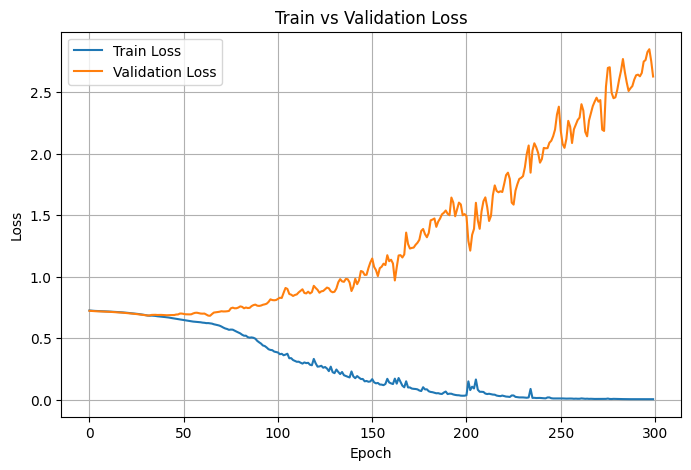

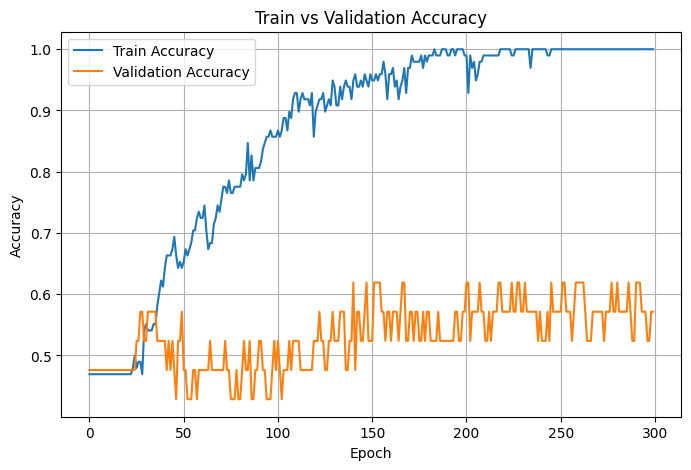


Final Test Loss: 1.7118539810180664
Final Test Accuracy: 0.5714285969734192


In [ ]:
import copy
import numpy as np
import matplotlib.pyplot as plt

EPOCHS = 300
PRINT_EVERY = 1

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_acc = -np.inf
best_val_loss = np.inf
best_epoch = 0
best_model_state = None

X_train_t = X_train_t.to(device)
X_val_t = X_val_t.to(device)

y_train_t = y_train_t.to(device)
y_val_t = y_val_t.to(device)

for epoch in range(EPOCHS):
    model.train()

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

    model.eval()

    with torch.no_grad():
        train_logits = model(X_train_t)
        val_logits = model(X_val_t)

        train_loss = criterion(train_logits, y_train_t).item()
        val_loss = criterion(val_logits, y_val_t).item()

        train_pred = torch.argmax(train_logits, dim=1)
        val_pred = torch.argmax(val_logits, dim=1)

        train_acc = (train_pred == y_train_t).float().mean().item()
        val_acc = (val_pred == y_val_t).float().mean().item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    if (val_acc > best_val_acc) or (val_acc == best_val_acc and val_loss < best_val_loss):
        best_val_acc = val_acc
        best_val_loss = val_loss
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())

    if epoch % PRINT_EVERY == 0 or epoch == EPOCHS - 1:
        print(
            f"Epoch [{epoch+1:03d}/{EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

print("\nBest Epoch:", best_epoch + 1)
print("Best Val Accuracy:", best_val_acc)
print("Best Val Loss:", best_val_loss)

# Load best validation model
model.load_state_dict(best_model_state)

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

X_test_t = X_test_t.to(device)
y_test_t = y_test_t.to(device)

model.eval()

with torch.no_grad():
    test_logits = model(X_test_t)
    test_loss = criterion(test_logits, y_test_t).item()

    test_pred = torch.argmax(test_logits, dim=1)
    test_acc = (test_pred == y_test_t).float().mean().item()

print("\nFinal Test Loss:", test_loss)
print("Final Test Accuracy:", test_acc)